In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime

# Analyse Descriptive

In [4]:
df = pd.read_excel('data/clean_data.xlsx')

In [5]:
df.head(3)

,DATE_OPERATION,ACT,SECT_ECON,PORTEF,MONTANT,DUREE,PERIODE,TAUX_INT,NB_ECH,SEXE,VALEURGARANT,AGENCELIB,IMPAYE,NBIMP,MNTREMB,DATENAIS,AGE,ETATCIVIL,SECT_ACTIV,WILAYA_NAISSANCE
0,20-APR-17,DD,Tertiaire,DD,16000000.0,96,T,8.0,32,Female,26000000,NOUAKCHOTT 1 - SIEGE,0.0,0,788565.21,1966-07-14,59,Married,AUTRES SOCIETES,Inconnu
1,19-FEB-13,DC,Tertiaire,DDC,1000000.0,48,M,8.0,48,Male,1089103,NOUAKCHOTT 1 - SIEGE,0.0,0,25608.95,1972-05-25,53,Married,ENTREPRISES INDIVIDUELLES,Inconnu
2,21-FEB-13,DC,Tertiaire,DDC,300000.0,36,M,6.0,36,Female,1180000,NOUAKCHOTT 1 - SIEGE,0.0,0,9293.61,1966-12-30,59,Divorced,ENTREPRISES INDIVIDUELLES,Inconnu


### PORTEF

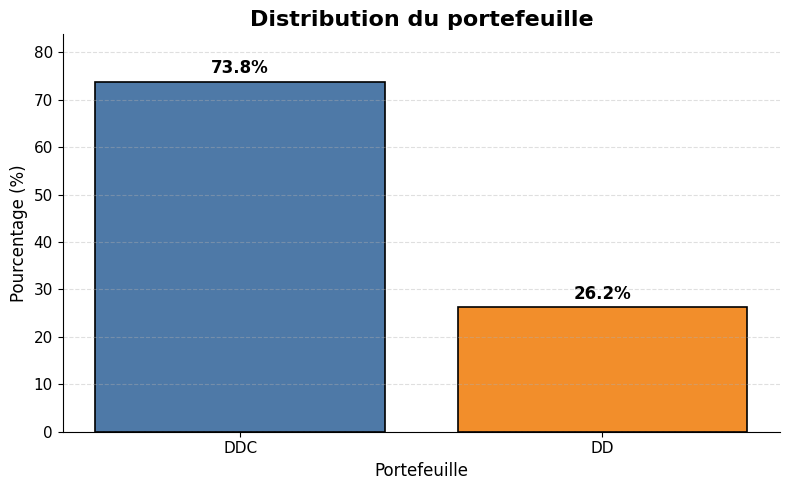

In [7]:
# Calcul des pourcentages
data = df['PORTEF'].value_counts(normalize=True).mul(100).sort_values(ascending=False)

# Couleurs personnalisées
colors = ['#4E79A7', '#F28E2B']  # bleu + orange professionnel

# Création du graphique
plt.figure(figsize=(8, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1.2
)

# Ajouter les pourcentages au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f'{height:.1f}%',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

# Personnalisation
plt.title('Distribution du portefeuille', fontsize=16, fontweight='bold')
plt.xlabel('Portefeuille', fontsize=12)
plt.ylabel('Pourcentage (%)', fontsize=12)

plt.ylim(0, data.max() + 10)
plt.xticks(rotation=0, fontsize=11)
plt.yticks(fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.4)

# Supprimer les bordures inutiles
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### Montant

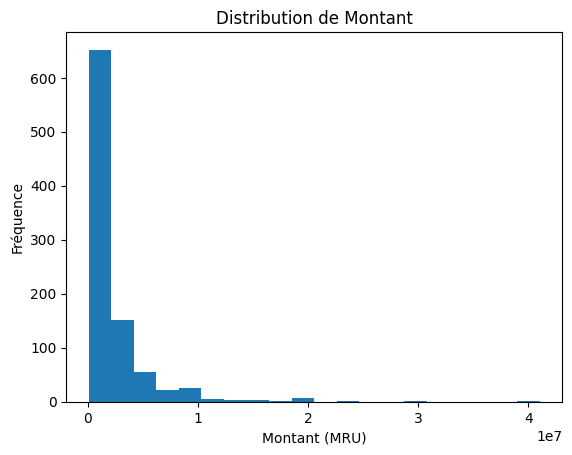

In [8]:
plt.hist(df['MONTANT'], bins=20)
plt.xlabel('Montant (MRU)')
plt.ylabel('Fréquence')
plt.title('Distribution de Montant')
plt.show()

<Axes: >

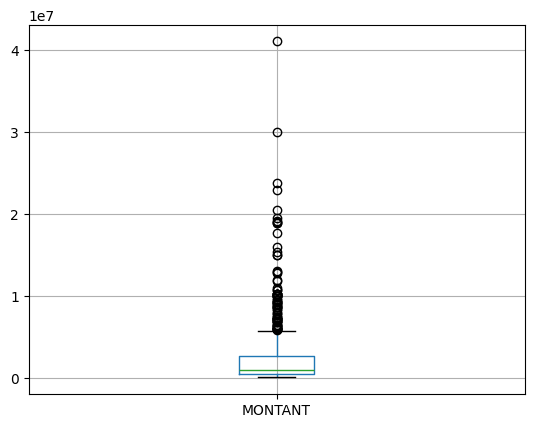

In [8]:
df.boxplot(column='MONTANT')

### Duree

In [9]:
df['DUREE'].describe()

count    927.000000
mean      50.933118
std        9.438207
min        8.000000
25%       48.000000
50%       48.000000
75%       60.000000
max      144.000000
Name: DUREE, dtype: float64

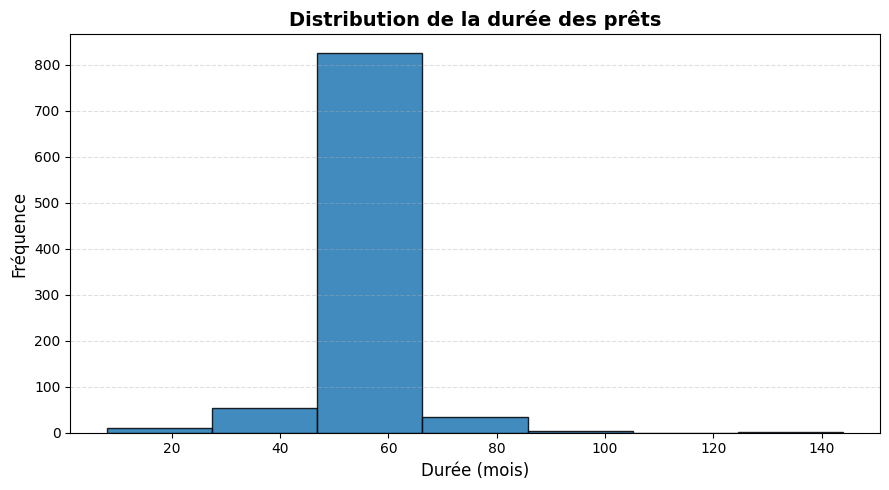

In [10]:
plt.figure(figsize=(9, 5))

plt.hist(
    df['DUREE'].dropna(),
    bins=7,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution de la durée des prêts", fontsize=14, fontweight='bold')
plt.xlabel("Durée (mois)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### PERIODE

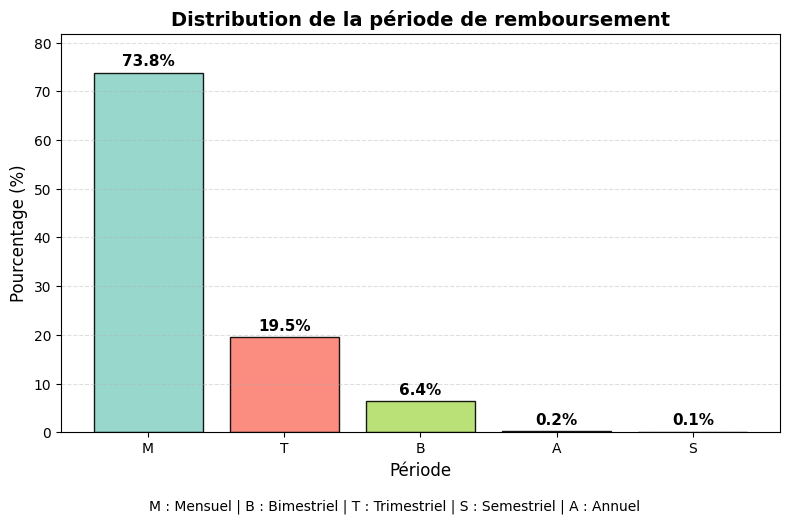

In [11]:
data = df['PERIODE'].value_counts(normalize=True).mul(100)

plt.figure(figsize=(8, 5))

colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

bars = plt.bar(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    alpha=0.9
)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Distribution de la période de remboursement", fontsize=14, fontweight='bold')
plt.xlabel("Période", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=0)
plt.ylim(0, data.max() + 8)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.figtext(
    0.5, -0.03,
    "M : Mensuel | B : Bimestriel | T : Trimestriel | S : Semestriel | A : Annuel",
    ha='center',
    fontsize=10
)

plt.tight_layout()
plt.show()

### TAUX_INT

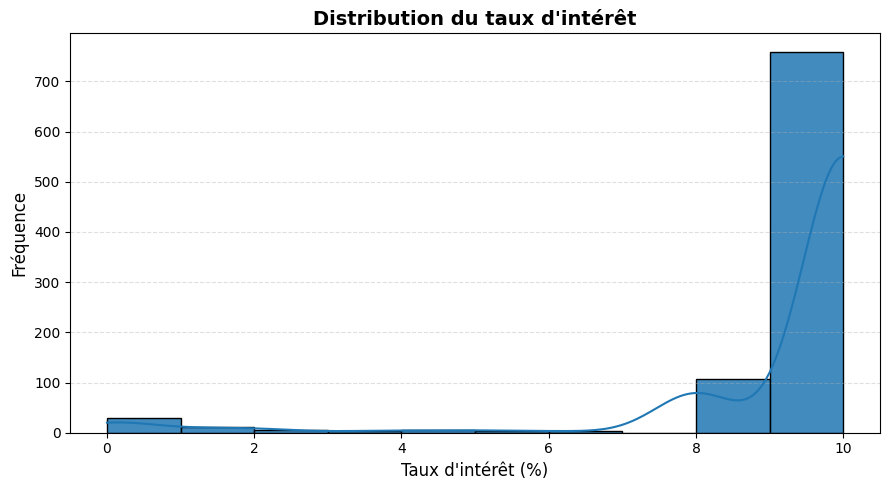

In [12]:
data = df['TAUX_INT'].dropna()

plt.figure(figsize=(9, 5))

sns.histplot(
    data,
    bins=10,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution du taux d'intérêt", fontsize=14, fontweight='bold')
plt.xlabel("Taux d'intérêt (%)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### NBRE ECH

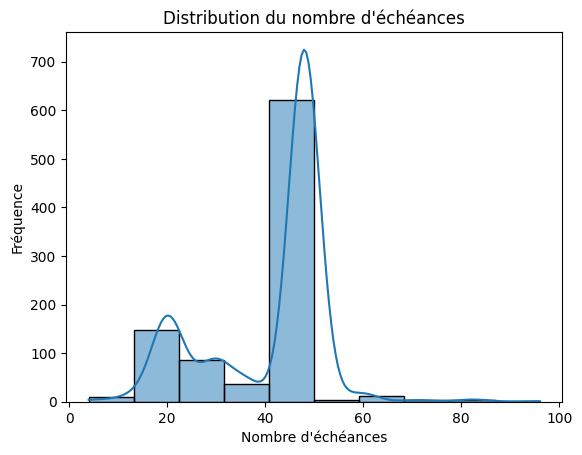

In [13]:
sns.histplot(df['NB_ECH'], bins=10, kde=True)

plt.xlabel("Nombre d'échéances")
plt.ylabel('Fréquence')
plt.title("Distribution du nombre d'échéances")
plt.show()

### VALEURGARANT

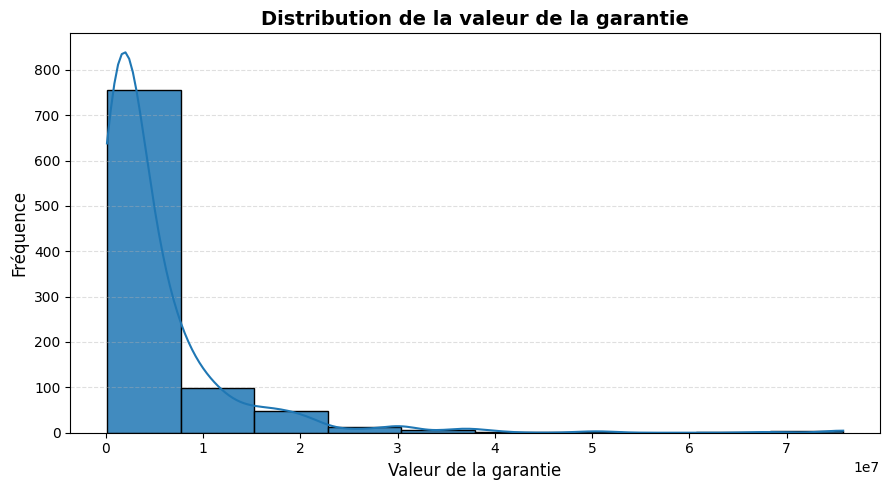

In [14]:
data = df['VALEURGARANT'].dropna()

plt.figure(figsize=(9, 5))

sns.histplot(
    data,
    bins=10,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution de la valeur de la garantie", fontsize=14, fontweight='bold')
plt.xlabel("Valeur de la garantie", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### AGENCELIB

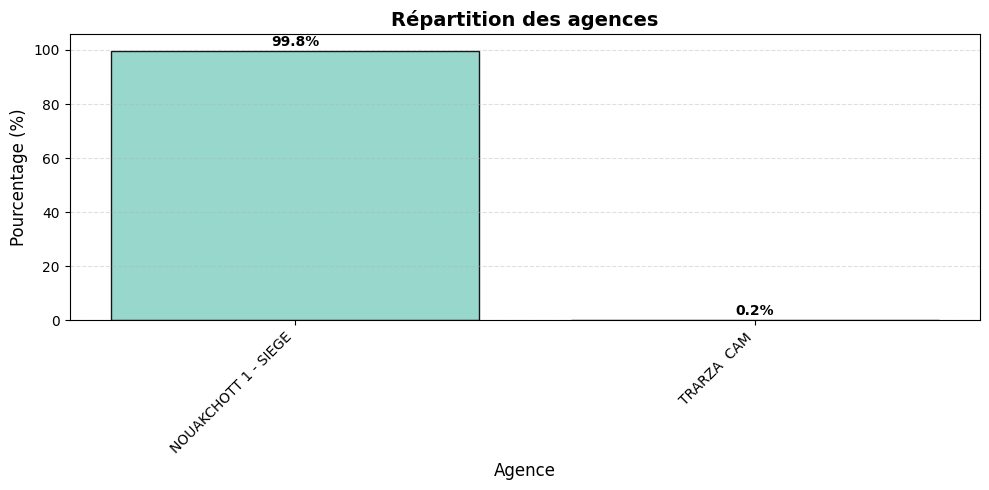

In [14]:
data = df['AGENCELIB'].value_counts(normalize=True).mul(100)

plt.figure(figsize=(10, 5))

colors = plt.cm.Set3(np.linspace(0, 1, len(data)))

bars = plt.bar(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    alpha=0.9
)

# Add percentages on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.5,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Répartition des agences", fontsize=14, fontweight='bold')
plt.xlabel("Agence", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=45, ha='right')
plt.ylim(0, data.max() + 6)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### IMPAYE & NBIMP

In [15]:
(df['IMPAYE'] == 0).sum() / (df['IMPAYE'].count())

np.float64(0.4519956850053937)

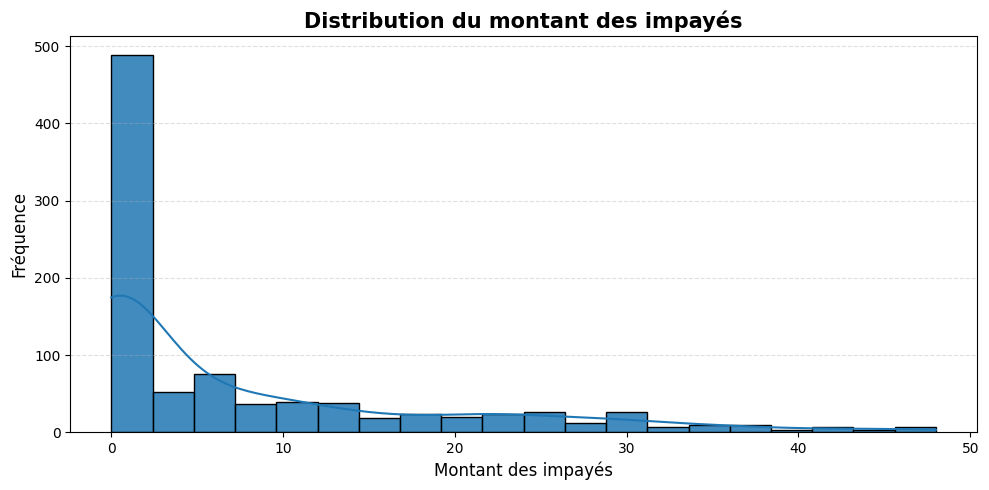

In [18]:
data = df['NBIMP'].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    data,
    bins=20,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution du montant des impayés", fontsize=15, fontweight='bold')
plt.xlabel("Montant des impayés", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

# Format x-axis as money values
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [19]:
(df['NBIMP'] == 0).sum() / df.shape[0]

np.float64(0.4519956850053937)

### MNTREMB

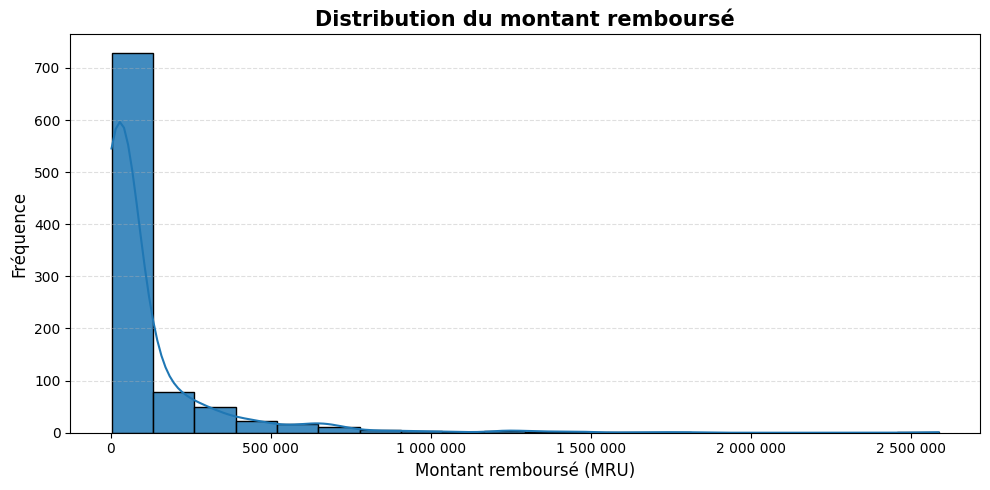

In [20]:
data = df['MNTREMB'].dropna()

plt.figure(figsize=(10, 5))

sns.histplot(
    data,
    bins=20,
    kde=True,
    edgecolor='black',
    alpha=0.85
)

plt.title("Distribution du montant remboursé", fontsize=15, fontweight='bold')
plt.xlabel("Montant remboursé (MRU)", fontsize=12)
plt.ylabel("Fréquence", fontsize=12)

# Format x-axis values with spaces
plt.gca().xaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x:,.0f}".replace(",", " "))
)

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

### SEXE

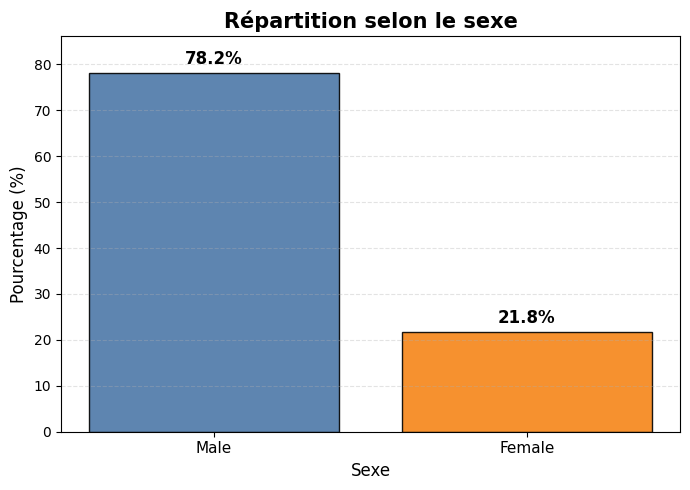

In [21]:
data = df['SEXE'].value_counts(normalize=True).mul(100)

# Cool standard colors
colors = ['#4C78A8', '#F58518']  # blue + orange

plt.figure(figsize=(7, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.title("Répartition selon le sexe", fontsize=15, fontweight='bold')
plt.xlabel("Sexe", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.ylim(0, data.max() + 8)
plt.xticks(rotation=0, fontsize=11)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### DATENAIS

In [22]:
df['DATENAIS'] = pd.to_datetime(
    df['DATENAIS'],
    errors='coerce',
    dayfirst=True
)



In [23]:
# Remove GROUP_AGE if it already exists
df = df.drop(columns=['GROUP_AGE'], errors='ignore')

# Create age groups
group_age = pd.cut(
    df['AGE'],
    bins=[0, 34, 44, 54, 64, 120],
    labels=['Moins de 35', '35-44', '45-54', '55-64', '65 et plus'],
    right=True
)

# Insert GROUP_AGE directly after AGE
pos = df.columns.get_loc('AGE') + 1
df.insert(pos, 'GROUP_AGE', group_age)

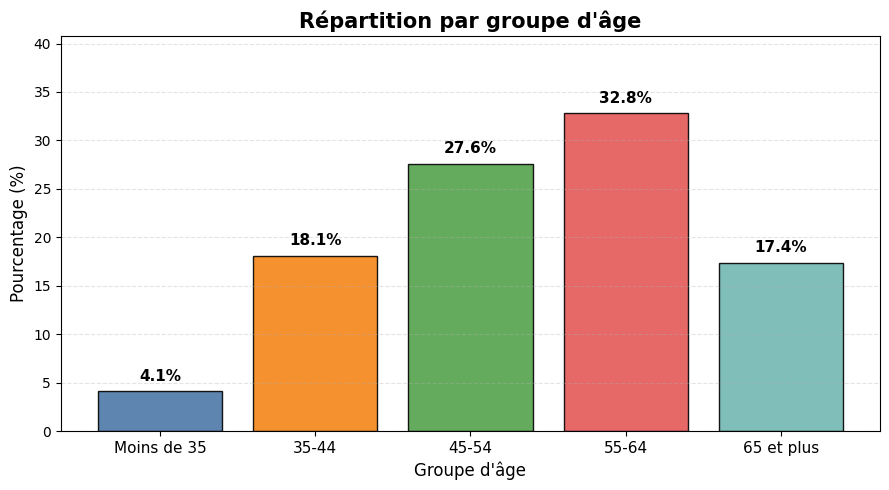

In [24]:
# Calculate percentages and keep the logical order of categories
ordre = ['Moins de 35', '35-44', '45-54', '55-64', '65 et plus']
data = (
    df['GROUP_AGE']
    .value_counts(normalize=True)
    .mul(100)
    .reindex(ordre)
)

# Clean and distinct colors
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2']

plt.figure(figsize=(9, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Add percentages on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Répartition par groupe d'âge", fontsize=15, fontweight='bold')
plt.xlabel("Groupe d'âge", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, data.max() + 8)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### ETAT CIVIL

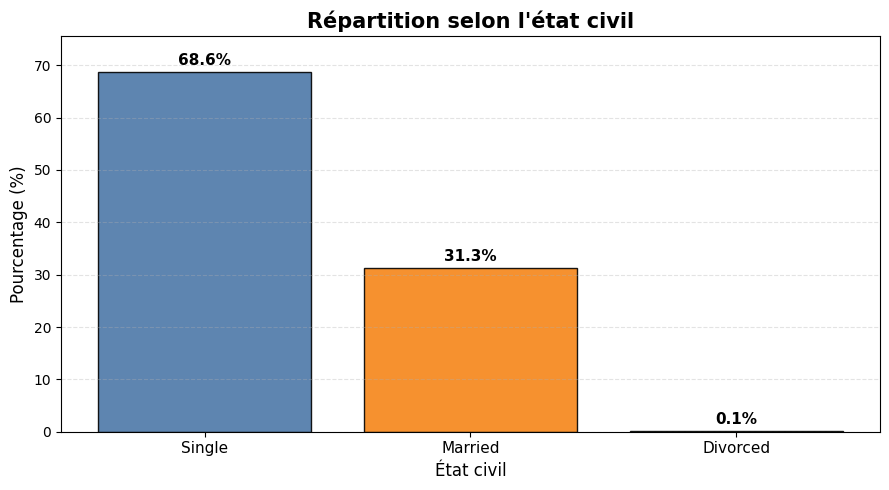

In [25]:
data = df['ETATCIVIL'].value_counts(normalize=True).mul(100)

# Cool standard colors
colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2', '#B279A2']

plt.figure(figsize=(9, 5))

bars = plt.bar(
    data.index,
    data.values,
    color=colors[:len(data)],
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Percentages on top
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,
        f"{height:.1f}%",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Répartition selon l'état civil", fontsize=15, fontweight='bold')
plt.xlabel("État civil", fontsize=12)
plt.ylabel("Pourcentage (%)", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, data.max() + 7)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

### WILAYA_NAISSANCE

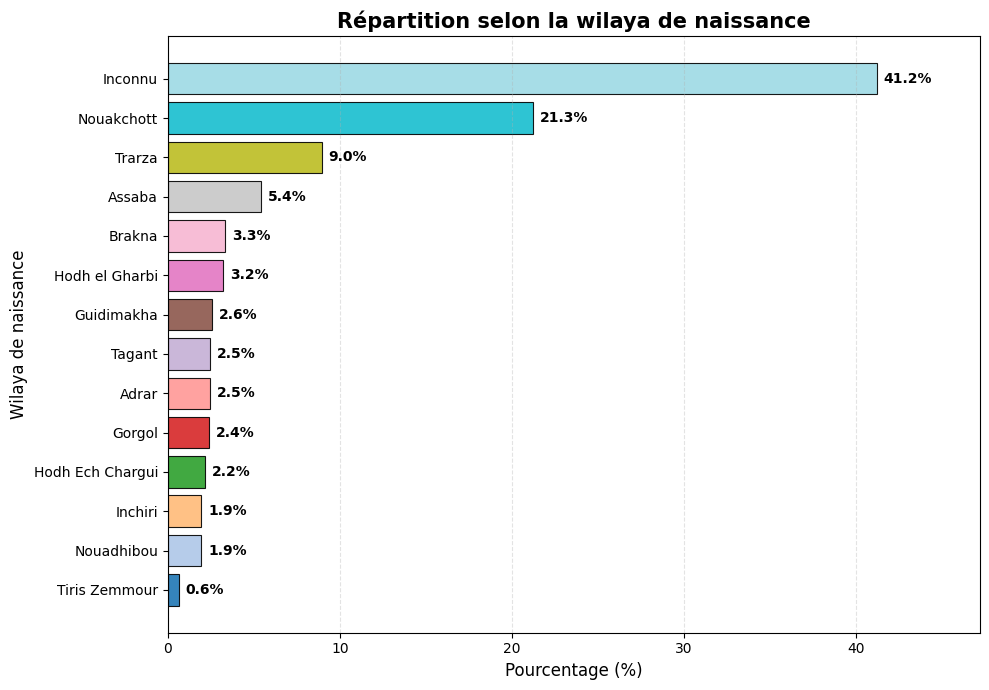

In [26]:
data = df['WILAYA_NAISSANCE'].value_counts(normalize=True).mul(100)

# Sort from largest to smallest
data = data.sort_values(ascending=True)

# Different colors for each bar
colors = plt.cm.tab20(np.linspace(0, 1, len(data)))

plt.figure(figsize=(10, 7))

bars = plt.barh(
    data.index,
    data.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

# Add percentages
for bar in bars:
    width = bar.get_width()
    plt.text(
        width + 0.4,
        bar.get_y() + bar.get_height() / 2,
        f"{width:.1f}%",
        va='center',
        fontsize=10,
        fontweight='bold'
    )

plt.title("Répartition selon la wilaya de naissance", fontsize=15, fontweight='bold')
plt.xlabel("Pourcentage (%)", fontsize=12)
plt.ylabel("Wilaya de naissance", fontsize=12)

plt.xlim(0, data.max() + 6)
plt.grid(axis='x', linestyle='--', alpha=0.35)

plt.tight_layout()
plt.show()

### STATUT_PRET

In [27]:
# Convert DATE_OPERATION to datetime
df['DATE_OPERATION'] = pd.to_datetime(df['DATE_OPERATION'], errors='coerce')

# Remove old columns if they already exist
df = df.drop(columns=['DATE_FIN_PRET', 'STATUT_PRET'], errors='ignore')

# Calculate loan end date
date_fin = df['DATE_OPERATION'] + df['DUREE'].apply(lambda x: pd.DateOffset(months=int(x)) if pd.notna(x) else pd.NaT)

# Insert DATE_FIN_PRET after DUREE
pos = df.columns.get_loc('DUREE') + 1
df.insert(pos, 'DATE_FIN_PRET', date_fin)

# Create status variable
today = pd.Timestamp.today().normalize()

statut_pret = np.where(
    df['DATE_FIN_PRET'].isna(),
    'Inconnu',
    np.where(df['DATE_FIN_PRET'] <= today, 'Terminé', 'En cours')
)

# Insert STATUT_PRET after DATE_FIN_PRET
pos = df.columns.get_loc('DATE_FIN_PRET') + 1
df.insert(pos, 'STATUT_PRET', statut_pret)

C:\Users\delli7\AppData\Local\Temp\ipykernel_17476\413121544.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['DATE_OPERATION'] = pd.to_datetime(df['DATE_OPERATION'], errors='coerce')
C:\Users\delli7\AppData\Local\Temp\ipykernel_17476\413121544.py:8: PerformanceWarning: Adding/subtracting object-dtype array to DatetimeArray not vectorized.
  date_fin = df['DATE_OPERATION'] + df['DUREE'].apply(lambda x: pd.DateOffset(months=int(x)) if pd.notna(x) else pd.NaT)


In [27]:
df[['DATE_OPERATION', 'DUREE', 'DATE_FIN_PRET', 'STATUT_PRET']].head()

,DATE_OPERATION,DUREE,DATE_FIN_PRET,STATUT_PRET
0,2017-04-20,96,2025-04-20 00:00:00,Terminé
1,2013-02-19,48,2017-02-19 00:00:00,Terminé
2,2013-02-21,36,2016-02-21 00:00:00,Terminé
3,2013-02-24,48,2017-02-24 00:00:00,Terminé
4,2013-02-27,36,2016-02-27 00:00:00,Terminé


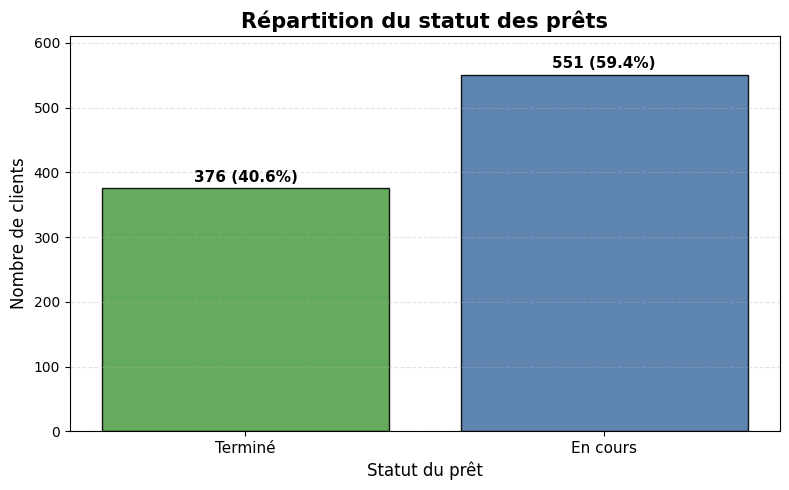

In [28]:
# Counts and percentages
counts = df['STATUT_PRET'].value_counts().reindex(['Terminé', 'En cours'])
percentages = df['STATUT_PRET'].value_counts(normalize=True).mul(100).reindex(['Terminé', 'En cours'])

# Clean colors
colors = ['#54A24B', '#4C78A8']  # green, blue

plt.figure(figsize=(8, 5))

bars = plt.bar(
    counts.index,
    counts.values,
    color=colors,
    edgecolor='black',
    linewidth=1,
    alpha=0.9
)

# Add count and percentage on each bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"{int(counts.iloc[i])} ({percentages.iloc[i]:.1f}%)",
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Répartition du statut des prêts", fontsize=15, fontweight='bold')
plt.xlabel("Statut du prêt", fontsize=12)
plt.ylabel("Nombre de clients", fontsize=12)

plt.xticks(rotation=0, fontsize=11)
plt.ylim(0, counts.max() + 60)

plt.grid(axis='y', linestyle='--', alpha=0.35)
plt.tight_layout()
plt.show()

# Analyse Bivarié

La variable cible ne mesure pas le défaut final du client, car certains prêts sont encore en cours. Elle mesure plutôt le niveau de risque observé au moment de l’étude, à partir du nombre d’échéances impayées, de la proportion d’échéances impayées et du poids du montant impayé par rapport au montant accordé.

In [30]:
# Avoid division by zero
df['TAUX_IMPAYE_NB'] = np.where(
    df['NB_ECH'] > 0,
    df['NBIMP'] / df['NB_ECH'],
    np.nan
)



df['TAUX_IMPAYE_MONTANT'] = np.where(
    df['MONTANT'] > 0,
    df['IMPAYE'] / df['MONTANT'],
    np.nan
)

# Create risk level
conditions = [
    (df['NBIMP'] == 0) & (df['IMPAYE'] == 0),

    (df['NBIMP'].between(1, 2)) |
    (df['TAUX_IMPAYE_NB'].between(0.01, 0.10)) |
    (df['TAUX_IMPAYE_MONTANT'].between(0.01, 0.10)),

    (df['NBIMP'].between(3, 12)) |
    (df['TAUX_IMPAYE_NB'].between(0.10, 0.30)) |
    (df['TAUX_IMPAYE_MONTANT'].between(0.10, 0.30)),

    (df['NBIMP'] > 12) |
    (df['TAUX_IMPAYE_NB'] > 0.30) |
    (df['TAUX_IMPAYE_MONTANT'] > 0.30)
]

choices = [
    'Aucun',
    'Faible',
    'Moyen',
    'Élevé'
]

df['NIVEAU_RISQUE'] = np.select(
    conditions,
    choices,
    default='Inconnu'
)